# H3 — Detection of Automation Misses (F1 / F2 / F3)

> **H3 (contrastive framing contrastive framing improves automation-miss detection).** Because the action-relevant fact
> is easier to read off a contrastive panel, participants detect a **higher
> proportion of automation-missed events** under the contrastive forms
> **F2 / F3** than under the verbose form **F1**.

**Design**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced). |
| Primary DV | **Miss-detection rate** | Of the **2** events per block the aid *skipped*, the proportion the participant caught manually. Higher = better. |
| Secondary DV | **Detection reaction time** | Time (ms) from the aid's panel firing to the participant's click, for *caught* misses only. Lower = faster extraction. |

Both DVs are read directly from the continuous OpenMATB platform log — no
questionnaire is involved in H3.

**Descriptive statistics and visualisations**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

## 1. Load the sessions and build the H3 metrics table

`find_study_sessions()` reads every study session under `session_logs/`. Each
session contributes three rows (one per form). The H3 metrics are produced by
`build_metrics_table()`, which uses the `automaticsolver` state at each event to
identify aid-skipped events and scores a HIT on a skipped event as a manual
detection.

In [2]:
sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
h3_cols = ["n_aid_miss_events", "n_detected", "detection_rate", "mean_detect_rt"]
table[["participant", "form", "block"] + h3_cols].sort_values(["participant", "form"]).reset_index(drop=True)

Reading logs from: C:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 12 study session(s).


,participant,form,block,n_aid_miss_events,n_detected,detection_rate,mean_detect_rt
0,P01,F1,A,2,1,0.5,6400.0
1,P01,F2,B,2,2,1.0,3100.0
2,P01,F3,C,2,2,1.0,3200.0
3,P02,F1,A,2,2,1.0,7000.0
4,P02,F2,C,2,2,1.0,4200.0
5,P02,F3,B,2,2,1.0,5300.0
6,P03,F1,B,2,2,1.0,2700.0
7,P03,F2,A,2,2,1.0,4100.0
8,P03,F3,C,2,2,1.0,4700.0
9,P04,F1,C,2,0,0.0,NaN


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every block should also show exactly **2 aid-miss
events** (`n_aid_miss_events == 2`); otherwise the detection rate's denominator is
off for that block.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

miss_counts = table["n_aid_miss_events"].value_counts().sort_index()
print("\nn_aid_miss_events per block (should all be 2):")
print(miss_counts.to_string())

12 session(s) validated; 0 with design issues.

n_aid_miss_events per block (should all be 2):
n_aid_miss_events
2    36


## 2. Primary DV — miss-detection rate by form

Descriptive statistics of the detection rate (proportion of the 2 aid-missed
events caught) for each form. With only 2 misses per block the rate can take just
three values — **0, 0.5, or 1.0** — so we report the mean, SD, median and the
spread, and below we also show the full distribution of how many misses (0/1/2)
were caught.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

det_desc = describe(table, "detection_rate")
det_desc

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,12,0.333,0.444,0.00,0.0,1.0
F2,12,0.500,0.477,0.50,0.0,1.0
F3,12,0.458,0.498,0.25,0.0,1.0


**Figure 1 — distribution of miss-detection rate by form.** Box = median and
interquartile range; whiskers = range; each dot is one block. H3 predicts the
F2/F3 distributions to sit above F1 (higher = more misses caught).

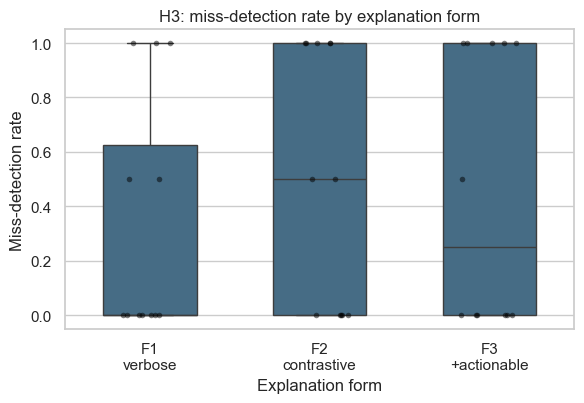

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="detection_rate", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="detection_rate", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Miss-detection rate")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H3: miss-detection rate by explanation form")
fig.tight_layout()
fig.savefig(OUT / "h3_detection_rate_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to improve from F1 to F2/F3, not just the
group average.

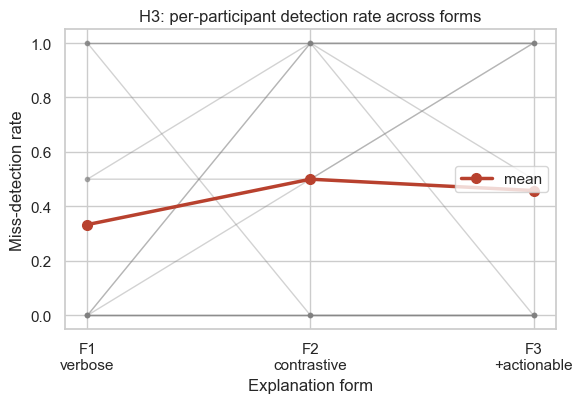

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="detection_rate")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Miss-detection rate")
ax.set_title("H3: per-participant detection rate across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h3_detection_rate_perparticipant.png", dpi=150)
plt.show()

**Figure 3 — distribution of how many of the 2 misses were caught.** For each
form, the share of blocks in which the participant caught 0, 1, or 2 of the misses.
This unpacks the coarse detection-rate values directly.

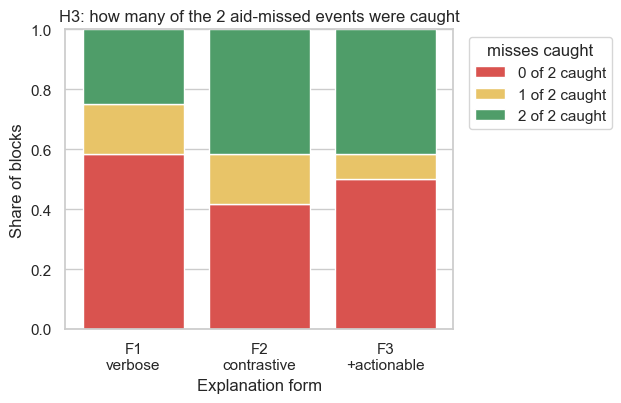

n_detected,0,1,2
form,,,
F1,0.583,0.167,0.250
F2,0.417,0.167,0.417
F3,0.500,0.083,0.417


In [7]:
dist = (table.groupby("form")["n_detected"].value_counts(normalize=True)
        .rename("share").reset_index())
dist = dist.pivot(index="form", columns="n_detected", values="share").reindex(FORM_ORDER)
dist = dist.reindex(columns=[0, 1, 2]).fillna(0.0)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
bottom = np.zeros(len(FORM_ORDER))
colors = {0: "#d9534f", 1: "#e8c468", 2: "#4f9d69"}
for k in [0, 1, 2]:
    vals = dist[k].values
    ax.bar([FORM_LABELS[f] for f in FORM_ORDER], vals, bottom=bottom,
           color=colors[k], label=f"{k} of 2 caught")
    bottom += vals
ax.set_ylabel("Share of blocks")
ax.set_xlabel("Explanation form")
ax.set_ylim(0, 1)
ax.set_title("H3: how many of the 2 aid-missed events were caught")
ax.legend(title="misses caught", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "h3_detection_distribution_by_form.png", dpi=150)
plt.show()
dist.round(3)

## 3. Secondary DV — detection reaction time (exploratory)

For the misses that *were* caught, how quickly did the participant click after the
panel fired? Lower = faster extraction of the action-relevant fact, which is the
mechanism H3 proposes.

**Missing data.** A block in which the participant caught **no** misses has no
reaction time (`mean_detect_rt` is `NaN`). These are reported and excluded from the
RT summary — they are not zeros. This is most common under F1, by H3's own logic.

In [8]:
n_blocks = table.groupby("form").size().reindex(FORM_ORDER)
n_missing_rt = table.assign(missing=table["mean_detect_rt"].isna()).groupby("form")["missing"].sum().reindex(FORM_ORDER)
missing_tbl = pd.DataFrame({"n_blocks": n_blocks, "blocks_without_RT": n_missing_rt,
                            "blocks_with_RT": n_blocks - n_missing_rt})
print("Reaction time is undefined for blocks where 0 misses were caught:")
print(missing_tbl.to_string())

rt_desc = describe(table.dropna(subset=["mean_detect_rt"]), "mean_detect_rt")
rt_desc

Reaction time is undefined for blocks where 0 misses were caught:
      n_blocks  blocks_without_RT  blocks_with_RT
form                                             
F1          12                  7               5
F2          12                  5               7
F3          12                  6               6


,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,5,5060.000,1722.788,5000.0,2700.0,7000.0
F2,7,4314.286,703.393,4200.0,3100.0,5400.0
F3,6,4550.000,1593.424,4400.0,2800.0,7200.0


**Figure 4 — detection reaction time by form (caught misses only).**

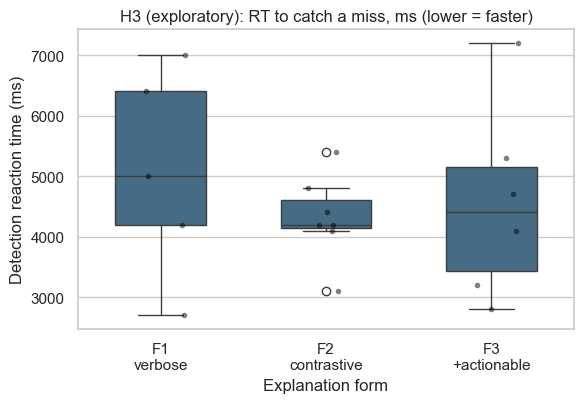

In [9]:
rt = table.dropna(subset=["mean_detect_rt"])
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=rt, x="form", y="mean_detect_rt", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=rt, x="form", y="mean_detect_rt", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Detection reaction time (ms)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H3 (exploratory): RT to catch a miss, ms (lower = faster)")
fig.tight_layout()
fig.savefig(OUT / "h3_detection_rt_by_form.png", dpi=150)
plt.show()